# Taxonomy Derivation

Discovers natural feedback categories from open-ended teacher descriptions via
sentence-transformer embedding and HDBSCAN clustering, then scores, selects,
and organizes them into a hierarchy.

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# All relative paths in this notebook expect CWD = model/
# VS Code sets CWD to the notebook's directory, so navigate up
if not os.path.isdir('src'):
    os.chdir(os.path.join(os.getcwd(), '..', '..'))

import sys
sys.path.insert(0, 'src')

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("data/masterclass_pipeline")
CACHE_DIR = Path("data/masterclass_cache")
OUTPUT_DIR = Path("data/composite_labels")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {os.getcwd()}")

Working directory: /Users/jdhiman/Documents/crescendai/model


## Load open-ended descriptions

In [2]:
from masterclass_experiments.clustering import load_open_descriptions

moment_ids, descriptions = load_open_descriptions(DATA_DIR / "all_moments.jsonl")
print(f"Loaded {len(descriptions)} open descriptions")

Loaded 2149 open descriptions


## Embed and cluster

In [3]:
import umap as umap_lib
from masterclass_experiments.clustering import embed_descriptions, cluster_descriptions, summarize_clusters

embeddings = embed_descriptions(descriptions)
print(f"Embeddings shape: {embeddings.shape}")

# Reduce to 15 dims before clustering -- HDBSCAN struggles in 384-d space
reducer = umap_lib.UMAP(n_components=15, random_state=42)
reduced = reducer.fit_transform(embeddings)

labels, clusterer = cluster_descriptions(reduced, min_cluster_size=10, min_samples=5)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f"Found {n_clusters} clusters, {n_noise} noise points ({n_noise/len(labels)*100:.1f}%)")

summary = summarize_clusters(descriptions, labels)
for s in summary:
    print(f"\nCluster {s['cluster_id']} (n={s['size']}, freq={s['frequency']:.1%}):")
    for ex in s['examples'][:5]:
        print(f"  - {ex}")

Embeddings shape: (2149, 384)


/Users/jdhiman/Documents/crescendai/model/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Found 49 clusters, 442 noise points (20.6%)

Cluster 0 (n=13, freq=0.8%):
  - fermata halting theme momentum
  - fermata sustain with imagined motion
  - unsteady e-flat fermata hold
  - missing fermata on last note
  - fermata too busy

Cluster 1 (n=19, freq=1.1%):
  - appoggiatura dissonance tension
  - softest entry with post-appoggiatura crescendo
  - sing appoggiatura with tension
  - appoggiaturas on second syllable
  - appoggiatura second syllable execution

Cluster 2 (n=35, freq=2.1%):
  - freer rubato evoking distant star
  - excessive rubato causing fussiness
  - excessive rubato in upper voice
  - stretch and rubato to fortissimo
  - slightly more rubato

Cluster 3 (n=17, freq=1.0%):
  - ritardando with sustained pedal
  - motive continuity without ritardando
  - extreme ritardando with orchestra
  - ritardando placement flexibility
  - open legato with ritardito

Cluster 4 (n=116, freq=6.8%):
  - left pedal for richer sound
  - staccato with pedal travel
  - staccato with l

## UMAP visualization

/Users/jdhiman/Documents/crescendai/model/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


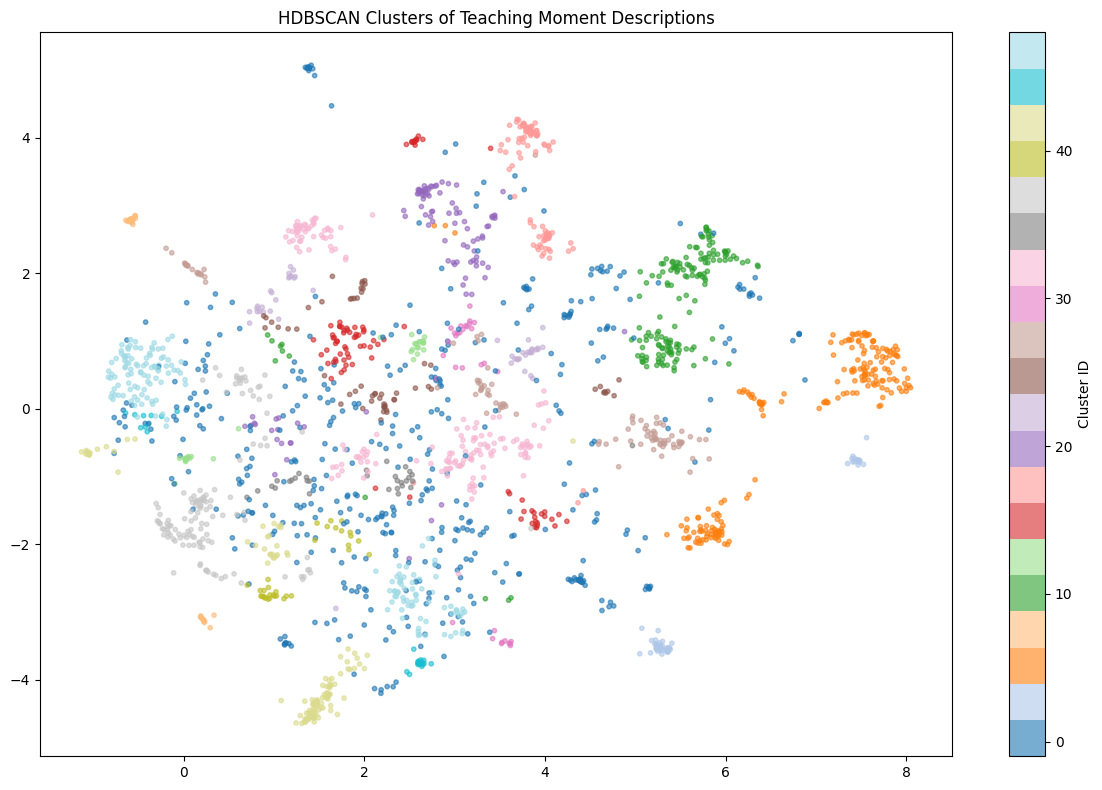

In [4]:
import umap

reducer = umap.UMAP(random_state=42)
coords = reducer.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab20', s=10, alpha=0.6)
ax.set_title("HDBSCAN Clusters of Teaching Moment Descriptions")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "cluster_umap.png"), dpi=150)
plt.show()

## Merge micro-clusters into musical dimensions

49 micro-clusters are too granular for the scoring/selection pipeline.
Group them into ~10 broad musical dimensions based on the cluster examples.

In [ ]:
# Merge 49 micro-clusters into 6 musical dimensions
DIMENSION_GROUPS = {
    "dynamics":       [12, 14, 17, 18, 20, 21],          # crescendo, diminuendo, forte, piano, volume
    "rhythm":         [0, 2, 3, 8, 30, 40, 41, 42, 43,
                       44, 47, 48],                       # tempo, rubato, fermata, rushing, syncopation, pulse
    "pedaling":       [4],                                # pedal usage
    "articulation":   [5, 6, 24, 27, 33, 45],            # staccato, accents, attacks, legato, bowing
    "phrasing":       [31, 35, 36, 37, 39],               # melodic shaping, line, breathing, phrase arc
    "interpretation": [1, 7, 9, 10, 11, 13, 15, 16, 19,
                       22, 23, 25, 26, 28, 29, 32, 34,
                       38, 46],                           # tone, voicing, expression, character, ornamentation
}

# Build micro-cluster -> macro-dimension lookup
cluster_to_dim = {}
for dim_name, cluster_ids in DIMENSION_GROUPS.items():
    for cid in cluster_ids:
        cluster_to_dim[cid] = dim_name

# Relabel: replace micro-cluster labels with macro-dimension IDs
dim_names_ordered = list(DIMENSION_GROUPS.keys())
dim_name_to_id = {name: i for i, name in enumerate(dim_names_ordered)}

merged_labels = np.full_like(labels, -1)
for i, lbl in enumerate(labels):
    if lbl >= 0 and lbl in cluster_to_dim:
        merged_labels[i] = dim_name_to_id[cluster_to_dim[lbl]]

# Report
n_assigned = (merged_labels >= 0).sum()
print(f"Merged {n_clusters} micro-clusters into {len(DIMENSION_GROUPS)} dimensions")
print(f"Assigned: {n_assigned}/{len(labels)} ({n_assigned/len(labels)*100:.1f}%), noise: {(merged_labels == -1).sum()}")
print()
for dim_name in dim_names_ordered:
    did = dim_name_to_id[dim_name]
    count = (merged_labels == did).sum()
    pct = count / n_assigned * 100 if n_assigned > 0 else 0
    clusters = DIMENSION_GROUPS[dim_name]
    print(f"  {dim_name:15s}: {count:4d} moments ({pct:5.1f}%) from clusters {clusters}")

# Replace labels for downstream pipeline
labels = merged_labels

## Multi-signal scoring

In [ ]:
from masterclass_experiments.scoring import (
    compute_teacher_frequency,
    compute_muq_predictability,
    select_dimensions,
    PERCEPIANO_MUQ_R2,
)

freq = compute_teacher_frequency(labels)
print("Teacher frequency per dimension:")
for did, f in sorted(freq.items()):
    name = dim_names_ordered[did] if did < len(dim_names_ordered) else f"dim_{did}"
    print(f"  {name:15s} (id={did}): {f:.1%}")

# PercePiano proxy mappings for each dimension
# drama dropped from interpretation (r=-0.82 with dynamic_range, measures dynamics not interpretation)
# timbre_brightness + mood_energy dropped (independent axis, r~0 with all interpretation proxies)
PP_MAPPING = {
    0: ["dynamic_range", "timbre_loudness"],                              # dynamics
    1: ["timing", "tempo"],                                               # rhythm
    2: ["pedal_amount", "pedal_clarity"],                                  # pedaling
    3: ["articulation_length", "articulation_touch"],                       # articulation
    4: ["space", "mood_imagination"],                                      # phrasing
    5: ["balance", "timbre_variety", "timbre_depth",
        "mood_valence", "interpretation", "sophistication"],               # interpretation
}

muq_scores = compute_muq_predictability(PP_MAPPING, PERCEPIANO_MUQ_R2)
print("\nMuQ predictability per dimension:")
for did, r2 in sorted(muq_scores.items()):
    name = dim_names_ordered[did] if did < len(dim_names_ordered) else f"dim_{did}"
    print(f"  {name:15s}: R2={r2:.3f}")

## Selection and hierarchy

In [7]:
# Build candidate scores dict and run selection
candidates = {}
for did in freq:
    candidates[did] = {
        "frequency": freq[did],
        "muq_r2": muq_scores.get(did, 0.0),
        "stop_delta_auc": 0.0,  # Fill after running STOP experiment
    }

kept, dropped, marginal = select_dimensions(candidates)

print(f"\nKept {len(kept)} dimensions, dropped {len(dropped)}, marginal {len(marginal)}")
for did, scores in sorted(kept.items()):
    name = dim_names_ordered[did]
    print(f"  {name:15s}: freq={scores['frequency']:.1%}, muq_r2={scores['muq_r2']:.3f}")
if marginal:
    print("\nMarginal (review manually):")
    for did, scores in marginal.items():
        name = dim_names_ordered[did]
        print(f"  {name:15s}: freq={scores['frequency']:.1%}, muq_r2={scores['muq_r2']:.3f}")

# Build hierarchy from kept clusters
from masterclass_experiments.scoring import build_hierarchy

kept_dims = []
for did in kept:
    mask = labels == did
    centroid = embeddings[mask].mean(axis=0)
    kept_dims.append({"name": dim_names_ordered[did], "centroid": centroid})

hierarchy = build_hierarchy(kept_dims, n_groups=3)
print("\nHierarchy:")
for group in hierarchy:
    print(f"  {group['group_name']}: {group['dimensions']}")


Kept 6 dimensions, dropped 0, marginal 0
  dynamics       : freq=14.1%, muq_r2=0.587
  rhythm         : freq=18.0%, muq_r2=0.332
  pedaling       : freq=6.8%, muq_r2=0.513
  articulation   : freq=11.4%, muq_r2=0.607
  phrasing       : freq=13.1%, muq_r2=0.569
  interpretation : freq=36.7%, muq_r2=0.524

Hierarchy:
  group_1: ['dynamics', 'articulation', 'phrasing', 'interpretation']
  group_2: ['rhythm']
  group_3: ['pedaling']


## Name dimensions and build quote bank

In [8]:
from masterclass_experiments.quote_bank import build_quote_bank

DIMENSION_NAMES = {i: name for i, name in enumerate(dim_names_ordered)}

# Build moment -> dimension assignments
all_moments = []
with open(DATA_DIR / "all_moments.jsonl") as f:
    for line in f:
        if line.strip():
            all_moments.append(json.loads(line))

assignments = {}
for mid, label in zip(moment_ids, labels):
    if label >= 0 and label in kept:
        assignments[mid] = DIMENSION_NAMES[label]

bank = build_quote_bank(all_moments, assignments)
print(f"Quote bank: {len(bank)} dimensions, {sum(len(q) for q in bank.values())} total quotes\n")
for dim, quotes in bank.items():
    print(f"{dim}: {len(quotes)} quotes")
    for q in quotes[:3]:
        print(f"  [{q['severity']}] {q['teacher']}: {q['feedback_summary']}")
    print()

Quote bank: 6 dimensions, 60 total quotes

interpretation: 10 quotes
  [significant] Murray Perahia: The playing is too weak and too fingery; play more legato and in one motion rather than separate finger articulations, as this motive returns later.
  [significant] Murray Perahia: Teacher instructs to follow the middle and lower voices instead of the top, avoid random accents, and shape the E-flat, F, G line continuously by imagining a connecting D for smooth phrasing. He emphasizes hearing the main notes clearly and softly.
  [significant] Murray Perahia: You're gonna have to work on that because it's too noddy and it doesn't have an atmosphere. It's a very beautiful thing, but if it's too fingery, it doesn't sound right.

articulation: 10 quotes
  [significant] Andras Schiff: Teacher instructs that each note must start with a consonant attack like 'pam, pam, pam', with proper key contact akin to a string player's bow on string, not surface hitting, emphasizing piano playing should ne

## Save taxonomy artifacts

In [ ]:
DIMENSION_DESCRIPTIONS = {
    "dynamics":       "Volume control, dynamic contrast, crescendo/diminuendo shaping",
    "rhythm":         "Tempo, rubato, ritardando, fermata, rhythmic patterns, syncopation, and pulse",
    "pedaling":       "Sustain and una corda pedal usage, clarity, and textural effects",
    "articulation":   "Note attack/release, staccato, legato, accents, and touch variety",
    "phrasing":       "Melodic line shaping, phrase arcs, breathing, and structural direction",
    "interpretation": "Tone quality, voicing, timbre, expression, character, ornamentation, and interpretive choices",
}

taxonomy_output = {
    "dimensions": {
        name: {"description": DIMENSION_DESCRIPTIONS[name]}
        for name in dim_names_ordered
        if dim_name_to_id[name] in kept
    },
    "hierarchy": hierarchy,
    "cluster_summary": summary,
    "dimension_groups": DIMENSION_GROUPS,
    "selection_scores": {dim_names_ordered[k]: v for k, v in candidates.items()},
}

with open(OUTPUT_DIR / "dimension_definitions.json", "w") as f:
    json.dump(taxonomy_output, f, indent=2)

with open(OUTPUT_DIR / "quote_bank.json", "w") as f:
    json.dump(bank, f, indent=2)

# Save cluster labels and moment IDs for notebook 02
np.savez(
    OUTPUT_DIR / "cluster_labels.npz",
    labels=labels,
    moment_ids=np.array(moment_ids, dtype=object),
)

print(f"Saved {len(taxonomy_output['dimensions'])} dimensions to {OUTPUT_DIR}")